<a href="https://colab.research.google.com/github/drtommyhudson77-ai/gdp-dashboard/blob/main/KMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [7]:
# Load dataset (assuming CSV file)
titanic = sns.load_dataset('titanic')
df = pd.DataFrame(titanic)

# Preview
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [8]:
data = df[['age', 'fare', 'pclass']].dropna()


In [10]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
kmeans = KMeans(n_clusters=3, random_state=42)
data['Cluster'] = kmeans.fit_predict(scaled_data)
print(data.head())


    age     fare  pclass  Cluster
0  22.0   7.2500       3        2
1  38.0  71.2833       1        1
2  26.0   7.9250       3        2
3  35.0  53.1000       1        1
4  35.0   8.0500       3        2


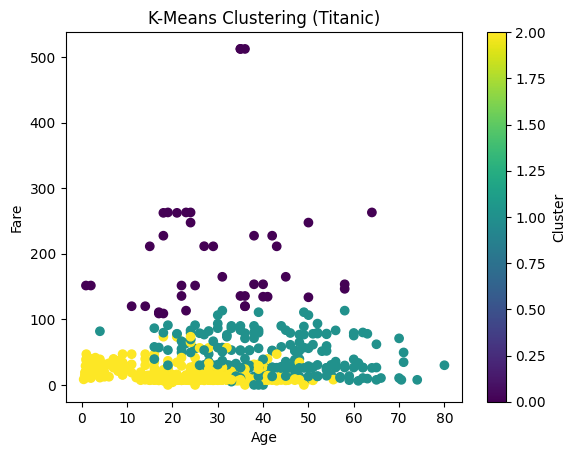

In [11]:
plt.scatter(data['age'], data['fare'], c=data['Cluster'], cmap='viridis')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('K-Means Clustering (Titanic)')
plt.colorbar(label='Cluster')
plt.show()

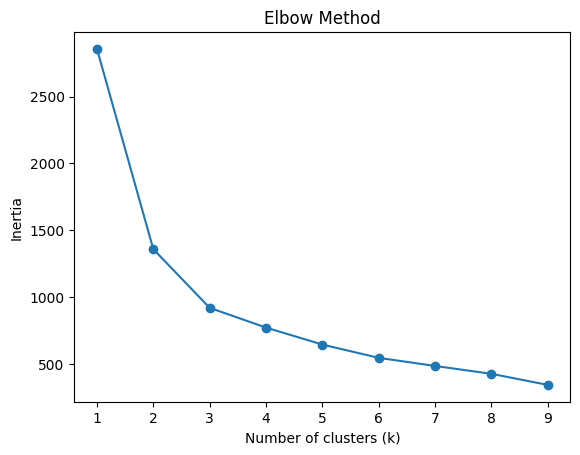

In [12]:
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [13]:
# Keep the same rows after dropping missing values
data = df[['age', 'fare', 'pclass', 'survived']].dropna()


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
scaled_features = scaler.fit_transform(data[['age', 'fare', 'pclass']])

kmeans = KMeans(n_clusters=3, random_state=42)
data['Cluster'] = kmeans.fit_predict(scaled_features)

In [16]:
# Mean = survival rate (since Survived is 0/1)
cluster_survival = data.groupby('Cluster')['survived'].mean()

print(cluster_survival)


Cluster
0    0.785714
1    0.538813
2    0.306843
Name: survived, dtype: float64


In [17]:
summary = data.groupby('Cluster').agg({
    'age': 'mean',
    'fare': 'mean',
    'pclass': 'mean',
    'survived': 'mean',
    'Cluster': 'count'
}).rename(columns={'Cluster': 'Count'})

print(summary)


               age        fare    pclass  survived  Count
Cluster                                                  
0        30.402857  200.267062  1.000000  0.785714     42
1        41.936073   43.013985  1.369863  0.538813    219
2        23.717991   15.321421  2.770419  0.306843    453


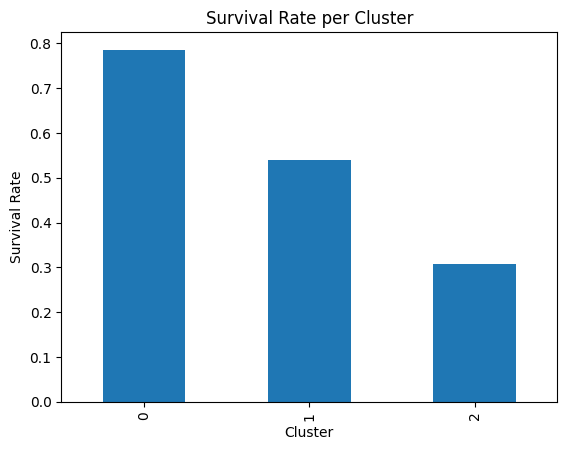

In [18]:
import matplotlib.pyplot as plt

cluster_survival.plot(kind='bar')
plt.title('Survival Rate per Cluster')
plt.ylabel('Survival Rate')
plt.xlabel('Cluster')
plt.show()
